In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sklearn.cluster
from sklearn import preprocessing
import umap
from collections import Counter
from sklearn.metrics import silhouette_score 
import matplotlib.pyplot as plt

# Choose the dataset

In [ ]:
# # n = 669
# n = 322
# number_of_topics = 19
# random_state = 916
# trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_ucsf_last_v3"

In [ ]:
# n = 615
# number_of_topics = 19
# random_state = 916
# trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_sinai_v1_2"

In [ ]:
# n = 825
# number_of_topics = 15
# random_state = 916
# trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_sinai_n825_v1"

In [ ]:
# n = 675
# number_of_topics = 19
# random_state = 916
# trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_emory_sinai_v1"

In [2]:
n = 318
number_of_topics = 18
random_state = 916
trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_cardiff_n318_v1"

In [3]:
file = f'{trained_topic_model_folder}/PFA_trained_model_n{n}_k{number_of_topics}.mat'
print(file)
data = sio.loadmat(file)
topic_proportions = data['Theta_mean'].T 
topic_proportions = topic_proportions/topic_proportions.sum(1)[:,np.newaxis]
topic_proportions = preprocessing.normalize(topic_proportions)
topic_proportions = pd.DataFrame(topic_proportions)
topic_proportions
UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=0)
embedding = UMAP.fit_transform(topic_proportions)

Subphenotyping-for-PASC_test/trained_topic_model_cardiff_n318_v1/PFA_trained_model_n318_k18.mat


In [4]:
cluster_df = pd.DataFrame()

In [5]:
def sorting(clusters): 
    # Sorting by cluster sizes
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    # [(1, 183), (3, 94), (5, 88), (9, 68), (2, 59), (8, 52), (7, 50), (4, 39), (6, 36)]
    mapping = dict(zip([val[0] for val in dictionary], np.unique(clusters))) # new:original
    # {1: 1, 3: 2, 5: 3, 9: 4, 2: 5, 8: 6, 7: 7, 4: 8, 6: 9}
    clusters = [mapping[val] for val in clusters]
    return clusters

In [6]:
# method = "AffinityPropagation"
# clustering = sklearn.cluster.AffinityPropagation(random_state = random_state).fit(topic_proportions)
# method_ = method
# cluster_df[method_] = sorting(clustering.labels_ + 1)
# print(len(np.unique(cluster_df[method_])))
# print(dict(Counter(cluster_df[method_])))

In [7]:
method = "AgglomerativeClustering"
for i in range(5, 31): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.AgglomerativeClustering(n_clusters = i).fit(topic_proportions)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))

5
{1: 96, 2: 79, 4: 53, 5: 25, 3: 65}
6
{3: 61, 5: 35, 1: 79, 4: 53, 6: 25, 2: 65}
7
{3: 61, 5: 35, 2: 64, 4: 53, 7: 15, 6: 25, 1: 65}
8
{3: 61, 7: 17, 2: 64, 4: 53, 8: 15, 6: 18, 5: 25, 1: 65}
9
{3: 61, 6: 17, 2: 64, 4: 53, 7: 15, 8: 14, 9: 4, 5: 25, 1: 65}
10
{2: 61, 7: 17, 4: 46, 3: 53, 8: 15, 9: 14, 10: 4, 6: 18, 5: 25, 1: 65}
11
{2: 61, 7: 17, 4: 46, 3: 53, 8: 15, 9: 10, 11: 4, 6: 18, 5: 25, 10: 4, 1: 65}
12
{2: 61, 7: 17, 3: 46, 9: 14, 8: 15, 4: 39, 10: 10, 12: 4, 6: 18, 5: 25, 11: 4, 1: 65}
13
{2: 61, 8: 17, 4: 28, 10: 14, 9: 15, 7: 18, 3: 39, 11: 10, 13: 4, 6: 18, 5: 25, 12: 4, 1: 65}
14
{1: 61, 8: 17, 4: 28, 11: 14, 10: 15, 7: 18, 3: 39, 12: 10, 14: 4, 6: 18, 5: 25, 13: 4, 2: 50, 9: 15}
15
{1: 55, 8: 17, 4: 28, 11: 14, 10: 15, 7: 18, 3: 39, 12: 10, 15: 4, 6: 18, 13: 6, 5: 25, 14: 4, 2: 50, 9: 15}
16
{1: 55, 9: 17, 4: 28, 12: 14, 11: 15, 8: 18, 2: 39, 13: 10, 16: 4, 7: 18, 14: 6, 5: 25, 15: 4, 3: 31, 6: 19, 10: 15}
17
{1: 55, 8: 17, 4: 28, 11: 14, 10: 15, 7: 18, 2: 39, 14: 10, 

In [8]:
method = "Birch"
for i in range(5, 31): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.Birch(n_clusters = i).fit(topic_proportions)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))

5
{1: 195, 2: 103, 4: 5, 5: 2, 3: 13}
6
{1: 195, 2: 103, 4: 5, 6: 2, 5: 4, 3: 9}
7
{1: 195, 3: 17, 5: 5, 7: 2, 2: 86, 6: 4, 4: 9}
8
{1: 193, 3: 17, 5: 5, 8: 2, 2: 86, 6: 4, 4: 9, 7: 2}
9
{1: 193, 3: 17, 5: 5, 9: 2, 2: 86, 6: 4, 4: 6, 7: 3, 8: 2}
10
{1: 189, 3: 17, 7: 4, 5: 5, 10: 2, 2: 86, 6: 4, 4: 6, 8: 3, 9: 2}
11
{1: 189, 3: 17, 7: 4, 5: 5, 10: 2, 2: 86, 6: 4, 4: 6, 11: 1, 9: 2, 8: 2}
12
{1: 106, 4: 17, 3: 83, 8: 4, 6: 5, 11: 2, 2: 86, 7: 4, 5: 6, 12: 1, 10: 2, 9: 2}
13
{1: 106, 5: 17, 2: 83, 9: 4, 7: 5, 12: 2, 4: 26, 8: 4, 6: 6, 3: 60, 13: 1, 11: 2, 10: 2}
14
{1: 106, 6: 17, 4: 34, 3: 49, 10: 4, 8: 5, 13: 2, 5: 26, 9: 4, 7: 6, 2: 60, 14: 1, 12: 2, 11: 2}
15
{1: 106, 6: 15, 4: 34, 3: 49, 10: 4, 8: 5, 14: 2, 5: 26, 9: 4, 7: 6, 2: 60, 15: 1, 13: 2, 12: 2, 11: 2}
16
{1: 87, 7: 15, 6: 19, 4: 34, 3: 49, 11: 4, 9: 5, 15: 2, 5: 26, 10: 4, 8: 6, 2: 60, 16: 1, 14: 2, 13: 2, 12: 2}
17
{1: 87, 7: 15, 6: 19, 4: 34, 3: 49, 12: 4, 10: 5, 16: 2, 9: 6, 11: 4, 5: 20, 8: 6, 2: 60, 17: 1, 15: 2, 14: 2

In [9]:
# method = "DBSCAN"
# clustering = sklearn.cluster.DBSCAN().fit(topic_proportions)
# method_ = method
# cluster_df[method_] = sorting(clustering.labels_ + 1)
# print(len(np.unique(cluster_df[method_])))
# print(dict(Counter(cluster_df[method_])))

In [10]:
# method = "HDBSCAN"
# clustering = sklearn.cluster.HDBSCAN().fit(topic_proportions)
# method_ = method
# cluster_df[method_] = sorting(clustering.labels_ + 1)
# print(len(np.unique(cluster_df[method_])))
# print(dict(Counter(cluster_df[method_])))

In [11]:
method = "KMeans"
for i in range(5, 31): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.KMeans(n_clusters = i, random_state = random_state).fit(topic_proportions)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))

5
{1: 107, 5: 39, 4: 45, 3: 50, 2: 77}
6
{1: 95, 6: 23, 5: 28, 4: 45, 3: 52, 2: 75}
7
{1: 87, 7: 18, 5: 38, 4: 40, 3: 44, 6: 35, 2: 56}
8
{1: 79, 7: 21, 4: 40, 5: 39, 3: 44, 8: 5, 6: 34, 2: 56}
9
{1: 79, 8: 18, 3: 37, 7: 19, 6: 32, 4: 35, 9: 9, 5: 33, 2: 56}
10
{1: 81, 8: 17, 7: 20, 6: 27, 4: 34, 3: 35, 9: 11, 10: 5, 5: 32, 2: 56}
11
{1: 75, 8: 18, 3: 37, 7: 19, 6: 32, 4: 35, 10: 9, 11: 4, 5: 33, 2: 41, 9: 15}
12
{1: 75, 9: 15, 6: 25, 5: 27, 3: 32, 11: 9, 10: 9, 8: 17, 12: 4, 4: 30, 2: 56, 7: 19}
13
{1: 61, 9: 18, 6: 26, 10: 11, 8: 19, 5: 29, 3: 33, 11: 7, 12: 5, 13: 4, 4: 30, 2: 56, 7: 19}
14
{1: 62, 9: 18, 6: 23, 7: 19, 11: 13, 5: 28, 3: 35, 8: 18, 13: 5, 14: 4, 4: 31, 12: 6, 2: 41, 10: 15}
15
{1: 67, 7: 18, 5: 25, 13: 11, 10: 16, 9: 16, 3: 27, 8: 17, 15: 4, 12: 12, 14: 6, 2: 37, 11: 15, 4: 25, 6: 22}
16
{1: 56, 8: 17, 4: 27, 11: 14, 6: 19, 10: 14, 5: 26, 3: 31, 13: 7, 15: 5, 16: 4, 12: 9, 14: 6, 2: 51, 9: 15, 7: 17}
17
{1: 59, 14: 7, 6: 24, 8: 16, 3: 26, 11: 13, 7: 19, 10: 13, 16: 5

In [12]:
method = "BisectingKMeans"
for i in range(5, 31): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.BisectingKMeans(n_clusters = i, random_state = random_state).fit(topic_proportions)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))

5
{1: 94, 5: 23, 4: 63, 3: 63, 2: 75}
6
{1: 88, 5: 23, 4: 63, 3: 63, 6: 6, 2: 75}
7
{2: 75, 5: 23, 6: 13, 4: 63, 3: 63, 7: 6, 1: 75}
8
{2: 75, 5: 23, 7: 13, 6: 20, 3: 63, 8: 6, 1: 75, 4: 43}
9
{2: 75, 6: 23, 8: 13, 7: 20, 4: 40, 5: 23, 9: 6, 1: 75, 3: 43}
10
{2: 70, 6: 23, 8: 13, 7: 20, 4: 40, 5: 23, 10: 5, 9: 6, 1: 75, 3: 43}
11
{1: 70, 6: 23, 9: 13, 8: 20, 4: 40, 5: 23, 11: 5, 10: 6, 7: 22, 2: 53, 3: 43}
12
{1: 60, 6: 23, 9: 13, 10: 10, 8: 20, 4: 40, 5: 23, 12: 5, 11: 6, 7: 22, 2: 53, 3: 43}
13
{1: 60, 6: 23, 10: 13, 11: 10, 8: 20, 3: 40, 5: 23, 13: 5, 12: 6, 7: 22, 2: 53, 9: 16, 4: 27}
14
{1: 60, 9: 16, 10: 13, 11: 10, 7: 20, 3: 40, 5: 23, 14: 5, 13: 6, 6: 22, 12: 7, 2: 53, 8: 16, 4: 27}
15
{1: 60, 9: 16, 11: 13, 12: 10, 7: 20, 4: 25, 5: 23, 15: 5, 14: 6, 6: 22, 13: 7, 2: 53, 10: 15, 8: 16, 3: 27}
16
{1: 60, 10: 16, 12: 13, 13: 10, 7: 20, 4: 25, 5: 23, 16: 5, 15: 6, 6: 22, 14: 7, 2: 37, 11: 15, 9: 16, 8: 16, 3: 27}
17
{1: 60, 9: 16, 12: 13, 13: 10, 6: 20, 4: 25, 11: 14, 17: 5, 16: 6

In [13]:
method = "MiniBatchKMeans"
for i in range(5, 31): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.MiniBatchKMeans(n_clusters = i, random_state = random_state).fit(topic_proportions)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))

5
{1: 102, 2: 74, 4: 49, 5: 36, 3: 57}
6
{1: 104, 4: 38, 3: 44, 6: 30, 2: 67, 5: 35}
7
{1: 81, 6: 21, 2: 68, 4: 48, 7: 11, 5: 33, 3: 56}
8
{1: 93, 6: 31, 7: 20, 4: 39, 8: 5, 5: 33, 2: 57, 3: 40}
9
{1: 79, 7: 20, 6: 28, 8: 19, 4: 36, 9: 5, 5: 33, 2: 56, 3: 42}
10
{1: 72, 7: 21, 4: 31, 10: 12, 9: 14, 6: 30, 3: 34, 5: 30, 2: 56, 8: 18}
11
{1: 64, 7: 17, 4: 39, 9: 10, 5: 36, 11: 8, 2: 45, 10: 8, 6: 35, 3: 41, 8: 15}
12
{1: 65, 9: 18, 5: 22, 6: 20, 8: 18, 10: 17, 11: 8, 12: 5, 4: 31, 2: 56, 7: 19, 3: 39}
13
{1: 67, 9: 16, 5: 22, 7: 18, 8: 17, 10: 15, 6: 20, 13: 5, 4: 30, 12: 6, 2: 56, 3: 39, 11: 7}
14
{1: 73, 12: 10, 5: 20, 10: 14, 9: 16, 4: 27, 3: 33, 14: 4, 11: 11, 8: 17, 13: 6, 2: 51, 6: 19, 7: 17}
15
{1: 63, 8: 16, 5: 22, 10: 14, 7: 16, 6: 21, 11: 13, 9: 15, 14: 5, 15: 4, 4: 28, 13: 6, 2: 56, 3: 32, 12: 7}
16
{1: 65, 7: 18, 3: 25, 14: 10, 8: 17, 10: 16, 6: 18, 9: 16, 15: 8, 16: 4, 13: 10, 2: 39, 4: 24, 12: 10, 11: 15, 5: 23}
17
{1: 70, 12: 14, 9: 15, 11: 14, 6: 16, 5: 22, 10: 14, 8: 15,

In [14]:
# method = "OPTICS"
# clustering = sklearn.cluster.OPTICS().fit(topic_proportions)
# method_ = method
# cluster_df[method_] = sorting(clustering.labels_ + 1)
# print(len(np.unique(cluster_df[method_])))
# print(dict(Counter(cluster_df[method_])))

In [15]:
method = "SpectralClustering"
for i in range(5, 31): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.SpectralClustering(n_clusters = i, random_state = random_state).fit(topic_proportions)
    cluster_df[method_] = sorting(clustering.labels_ + 1)
    print(len(np.unique(cluster_df[method_])))
    print(dict(Counter(cluster_df[method_])))

5
{1: 114, 5: 40, 4: 46, 2: 71, 3: 47}
6
{1: 114, 6: 21, 5: 27, 3: 48, 2: 66, 4: 42}
7
{1: 89, 7: 19, 5: 33, 4: 44, 3: 49, 2: 53, 6: 31}
8
{1: 89, 7: 18, 6: 32, 4: 43, 8: 4, 3: 45, 2: 53, 5: 34}
9
{1: 87, 8: 18, 7: 20, 6: 24, 3: 42, 9: 4, 4: 40, 2: 54, 5: 29}
10
{1: 84, 8: 18, 7: 20, 6: 22, 3: 42, 10: 4, 4: 41, 9: 5, 2: 53, 5: 29}
11
{1: 81, 9: 15, 8: 21, 7: 22, 4: 38, 6: 25, 11: 4, 3: 38, 10: 4, 2: 42, 5: 28}
12
{1: 79, 10: 14, 9: 18, 8: 20, 5: 26, 4: 27, 12: 4, 3: 39, 11: 5, 7: 22, 2: 42, 6: 22}
13
{1: 77, 10: 12, 9: 19, 7: 21, 6: 22, 4: 28, 11: 9, 12: 4, 3: 37, 13: 3, 2: 41, 8: 20, 5: 25}
14
{1: 61, 11: 15, 5: 25, 10: 17, 9: 17, 4: 29, 7: 21, 12: 9, 13: 4, 3: 35, 14: 3, 2: 41, 8: 19, 6: 22}
15
{1: 68, 11: 15, 5: 23, 9: 17, 6: 22, 7: 21, 13: 8, 14: 4, 12: 8, 15: 3, 3: 33, 2: 39, 8: 19, 10: 15, 4: 23}
16
{1: 65, 13: 11, 6: 19, 10: 16, 11: 15, 7: 18, 8: 17, 14: 9, 15: 4, 9: 16, 16: 3, 2: 37, 3: 34, 5: 19, 12: 13, 4: 22}
17
{1: 63, 13: 12, 11: 14, 10: 15, 6: 20, 8: 16, 7: 17, 15: 5, 16:

In [18]:
# Getting the best score per clustering method
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
columns = []
dictionary = {}
silhouette_scores = pd.DataFrame()
for col in cluster_df.columns: 
    silhouette_avg = silhouette_score(topic_proportions, cluster_df[col])
    key = col.split("_")[0]
    if key not in dictionary or dictionary[key][1] < silhouette_avg: 
        dictionary[key] = (col, silhouette_avg)
    score = silhouette_score(topic_proportions, cluster_df[col])
    silhouette_scores = pd.concat([silhouette_scores, pd.DataFrame({"cluster": [col], "score": [score]})])
dictionary

{'AgglomerativeClustering': ('AgglomerativeClustering_11', 0.2821570525926179),
 'Birch': ('Birch_16', 0.3035896565677554),
 'KMeans': ('KMeans_6', 0.30055706487707073),
 'BisectingKMeans': ('BisectingKMeans_5', 0.27820002101404584),
 'MiniBatchKMeans': ('MiniBatchKMeans_25', 0.28544848770921616),
 'SpectralClustering': ('SpectralClustering_10', 0.2912192045420677)}

In [19]:
df = pd.DataFrame()
for key in dictionary.keys(): 
    df = pd.concat([df, pd.DataFrame({"method": [dictionary[key][0]], "score": [dictionary[key][1]]})])
df = df.sort_values("score")
df

,method,score
0,BisectingKMeans_5,0.278200
0,AgglomerativeClustering_11,0.282157
0,MiniBatchKMeans_25,0.285448
0,SpectralClustering_10,0.291219
0,KMeans_6,0.300557
0,Birch_16,0.303590


In [20]:
# a = plt.barh(df["method"], df["score"])
# a = plt.xlabel("silhouette_coefficient")

In [21]:
# method = "MiniBatchKMeans_"
# if "_" in method: 
#     method = method.split("_")[0]
#     subset = silhouette_scores[silhouette_scores["cluster"].isin([method + "_" + str(i) for i in range(5, 26)])]
#     plt.scatter(range(5, 26), subset["score"])
#     plt.title(method)
# #     plt.savefig(file.replace(".mat", ".png"))

In [22]:
silhouette_scores_ = silhouette_scores[~silhouette_scores.duplicated("score", keep = "first")]
silhouette_scores_.sort_values("score", ascending = False).iloc[:10,:]

,cluster,score
0,Birch_16,0.303590
0,Birch_19,0.301378
0,Birch_17,0.300849
0,KMeans_6,0.300557
0,KMeans_10,0.300075
0,KMeans_12,0.293017
0,SpectralClustering_10,0.291219
0,KMeans_8,0.291050
0,SpectralClustering_8,0.288485
0,Birch_18,0.288378


n: 318
random_state: 916 

Subphenotyping-for-PASC_test/trained_topic_model_cardiff_n318_v1/PFA_trained_model_n318_k18.mat
number_of_topics: 18
n_clusters: 6


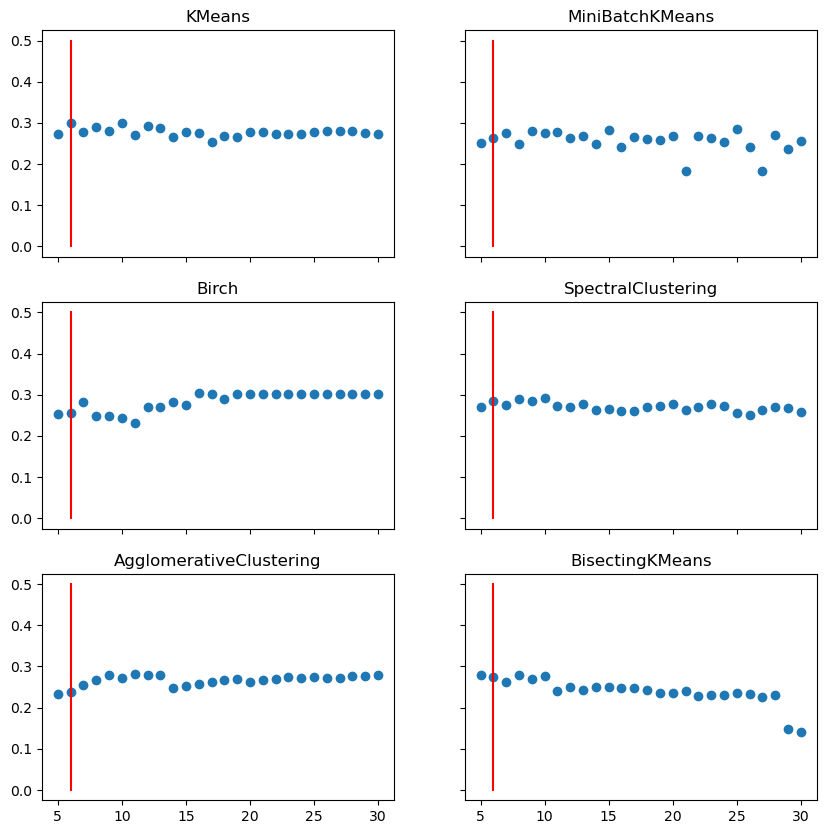

In [25]:
n_clusters = 6

# Getting top 6 methods
methods = list(df.sort_values("score", ascending = False)["method"])[:6]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
ax = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)]
methods = ["KMeans_", "MiniBatchKMeans_", "Birch_", "SpectralClustering_", "AgglomerativeClustering_", "BisectingKMeans_"]
for m in range(len(methods)): 
    method = methods[m]
    if "_" in method: 
        method = method.split("_")[0]
        subset = silhouette_scores[silhouette_scores["cluster"].isin([method + "_" + str(i) for i in range(5, 31)])]
        axes[ax[m][0], ax[m][1]].scatter(range(5, 31), subset["score"])
        axes[ax[m][0], ax[m][1]].set_title(method)
        axes[ax[m][0], ax[m][1]].plot([n_clusters, n_clusters], [0, 0.5], color = "red")
    else: 
        subset = silhouette_scores[silhouette_scores["cluster"] == method]
        axes[ax[m][0], ax[m][1]].bar(range(5, 26), list(subset["score"])[0])
for axes in fig.get_axes():
    axes.label_outer()
# fig.savefig(file.replace(".mat", ".png"))
print("n:", n)
print("random_state:", random_state, "\n")
print(file)
print("number_of_topics:", number_of_topics)
print("n_clusters:", n_clusters)

# Iteratively subclustering

In [ ]:
n = 825
number_of_topics = 15
n_clusters = 16
clustering_method = "kmeans"
trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_sinai_n825_v1"
print(f'results_sinai_n{n}_{number_of_topics}topics_{n_clusters}clusters_v{trained_topic_model_folder.split("_v")[-1]}')

file = f'{trained_topic_model_folder}/PFA_trained_model_n{n}_k{number_of_topics}.mat'
data = sio.loadmat(file) 
print(file)

colors = list(sns.color_palette("tab20"))
colors.extend(["purple", "black", "yellow", "green", "blue", "pink", "cyan", "cyan", "cyan"])

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
def get_clusters(method, n_clusters, topic_proportions): 
    method = method.lower()
    if method == "kmeans": 
        clusters = sklearn.cluster.KMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "minibatch": 
        clusters = sklearn.cluster.MiniBatchKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "spectralclustering": 
        clusters = sklearn.cluster.SpectralClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "birch": 
        clusters = sklearn.cluster.Birch(n_clusters = n_clusters).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "agglomerativeclustering": 
        clusters = sklearn.cluster.AgglomerativeClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "bisectingkmeans": 
        clusters = sklearn.cluster.BisectingKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    # Sorting by cluster sizes
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    # [(1, 183), (3, 94), (5, 88), (9, 68), (2, 59), (8, 52), (7, 50), (4, 39), (6, 36)]
    mapping = dict(zip([val[0] for val in dictionary], np.unique(clusters))) # new:original
    # {1: 1, 3: 2, 5: 3, 9: 4, 2: 5, 8: 6, 7: 7, 4: 8, 6: 9}
    clusters = [mapping[val] for val in clusters]
    df = pd.DataFrame()
    df[0] = clusters
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    return clusters
def plot_clusters(clusters, embedding, title, colors, topic_proportions_, highlights): 
    plt.figure()
    fig, ax = plt.subplots()
    plt.title(title)
    legend_elements = [] 
    for i in np.unique(clusters):
        a = plt.scatter(embedding[clusters==i, 0], embedding[clusters==i, 1], c = colors[i], s = 5)
        label = f"C{i}: {dict(Counter(clusters))[i]}"
        legend_elements.append(Line2D([0], [0], label = label, markerfacecolor = colors[i], markersize = 5, marker = 'o', color = 'w'))
        if highlights: 
            indeces = topic_proportions_[topic_proportions_["cluster"] == i].index
            indeces = list(set(indeces) & set(patients))
            a = plt.scatter(embedding[indeces, 0], embedding[indeces, 1], c = colors[i], s = 100, alpha = 0.5, marker = "^")
    ax.legend(handles = legend_elements, bbox_to_anchor=(1, 1))

In [ ]:
topic_proportions = pd.DataFrame(data['Theta_mean']).T
topic_proportions_norm = topic_proportions/topic_proportions.sum(1)[:,np.newaxis]
topic_proportions_norm = preprocessing.normalize(topic_proportions)
UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=916)
embedding = UMAP.fit_transform(topic_proportions_norm)
clusters = get_clusters(clustering_method, n_clusters, topic_proportions = topic_proportions)
topic_proportions_ = pd.DataFrame(topic_proportions).copy()
topic_proportions_["cluster"] = clusters
print(Counter(clusters))
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')
plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

In [ ]:
for cluster in np.unique(topic_proportions_["cluster"]): 
    subset = topic_proportions_[topic_proportions_["cluster"] == cluster]
    del subset["cluster"]
    subset_norm = subset/subset.sum(1)[:,np.newaxis]
    subset_norm = preprocessing.normalize(subset)
    UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=916)
    embedding = UMAP.fit_transform(subset_norm)
    clusters = get_clusters(clustering_method, 2, topic_proportions = subset)
    subset["cluster"] = clusters
    print(Counter(clusters))
#     plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)
    break
subset

In [ ]:
method = "KMeans"
for i in range(2, 11): 
    method_ = method + "_" + str(i)
    clustering = sklearn.cluster.KMeans(n_clusters = i, random_state = random_state).fit(subset)
    print(clustering)

In [ ]:
subset